<a href="https://colab.research.google.com/github/thalitadru/ml-class-epf/blob/main/LabAssignmentRNNsRidershipTimeSeries_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Processing Sequences Using RNNs (and CNNs)

*Credits:* Based on code written by [A. Géron](https://colab.research.google.com/github/ageron/handson-ml3/blob/master/15_processing_sequences_using_rnns_and_cnns.ipynb) for his "Hands-on ML" book. Code realeased under MIT license.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In this activity we are going to explore different ways of modelling sequential data. We will try out simple baseline models as well as 1D CNNs and different RNNs to **forecast the next step in a time series**.

## Loading a real-world ridership dataset
We will use the [Chicago Transit Authority daily ridership dataset](https://data.cityofchicago.org/Transportation/CTA-Ridership-Daily-Boarding-Totals/6iiy-9s97/about_data). We will forecast rail ridership from previous observations.

In [144]:
from pathlib import Path

dir = tf.keras.utils.get_file(
    "ridership.tgz",
    "https://github.com/ageron/data/raw/main/ridership.tgz",
    cache_dir=".", extract=True)

path = Path(dir) / "ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date","day_type","bus","rail","total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total",axis=1).drop_duplicates()


In [145]:
df

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830


## Splitting time series data
For time-series data, it is important **not to shuffle observations** and to preserve the chronological order by using contiguous time intervals.

We use:

- **2016-2018** for training,
- **2019** for validation,
- **2020 onward** for testing.

The training set is large enough to learn seasonal patterns, the validation set covers a full year to compare model performances reliably, and the test set is reserved for the final evaluation.

For this notebook, we will model the **number of daily passengers** (the `rail` variable).

In [146]:
# Split based on dates
# and also rescalling data to lower values for easier optimization convergence
rail_train = df["rail"]["2016-01":"2018-12"] / 1e6
rail_valid = df["rail"]["2019-01":"2019-12"] / 1e6
rail_test = df["rail"]["2020-01":] / 1e6


In [147]:
"Rail series length:", len(rail_train), len(rail_valid), len(rail_test)

('Rail series length:', 1096, 365, 700)

## Prediction task 1 : forecast one time step

We want to predict a single continuous value for each input sequence. This can be seen as a sequence-to-vector regression task. As seen in class, a suitable loss function is the `keras.losses.mean_squared_error` (as derived by MLE under a Gaussian assumption on the prediciton targets).


As we try out different models, keep the models and their validation performances. In the end you will compare their performances in validation to pick the best model (which will be applied to the test set).

### Creating prediction targets

We want to predict one step further into the series. To do so, we use the last value after a window as the prediction target, while the preceding values serve as inputs.

A practical question is: **how much history should we provide to the model?**

Public transport ridership exhibits a strong weekly seasonality. Using a 56-day window gives the model access to 8 full weeks of past observations. This allows it to observe multiple repetitions of the weekly pattern while still keeping the input sequences reasonably short.

The optimal window size depends on the problem and is typically treated as a hyperparameter. Here we use 56 days because it is long enough to capture the main seasonal structure of the data while keeping training reasonably fast.

In [148]:
n_steps = 56

def make_windows(series, window):
    X, y = [], []
    arr = series.to_numpy()
    for i in range(len(arr) - window):
        X.append(arr[i:i+window])
        y.append(arr[i+window])
    return np.array(X)[..., np.newaxis], np.array(y)[..., np.newaxis]

X_train_one, y_train_one = make_windows(rail_train, n_steps)
X_valid_one, y_valid_one = make_windows(rail_valid, n_steps)
X_test_one, y_test_one = make_windows(rail_test, n_steps)


Notice the shape of the series array:


In [149]:
X_train_one.shape, y_train_one.shape

((1040, 56, 1), (1040, 1))

The meaning of each dimension is `[samples, time steps, sequence element size]`.

Here each series element is a single scalar because we are making a univariate prediction.
If we were modeling mutiple time series at once (eg. temperature and humidity) this would be a multi-variate prediction and our sequence element size would be 2.

### Visualizing the data
This function plots a window along with the prediction target (and the predicted value if given).
Let's use it to plot the first window from the validation set.

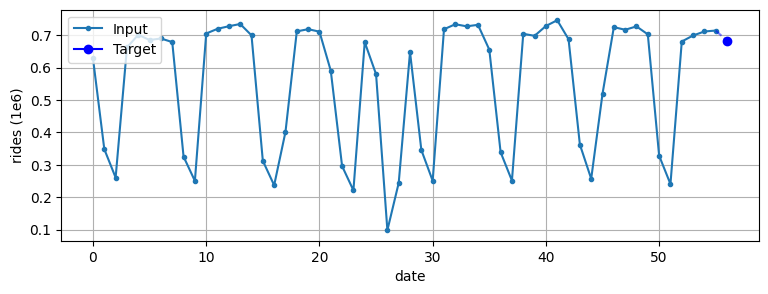

In [283]:
def plot_window(X, Y=None, Y_pred=None):
    X = np.asarray(X).squeeze()
    plt.plot(np.arange(len(X)), X, ".-", label="Input")

    # plotting target marker
    if Y is not None:
        # ensure one-dim, remove singleton dims
        Y = np.ravel(Y)

        plt.plot(np.arange(len(X), len(X) + len(Y)), Y,
            "bo-", label="Target")
        plt.plot([n_steps - 1, n_steps], [X[-1], Y[0]],
            "b--", alpha=0.5)

    # plotting prediction marker
    if Y_pred is not None:
        Y_pred = np.ravel(Y_pred)

        plt.plot(np.arange(len(X), len(X) + len(Y_pred)), Y_pred,
            "rx-", label="Prediction")
        plt.plot([n_steps - 1, n_steps], [X[-1], Y_pred[0]],
            "r--", alpha=0.5)


    plt.grid(True)
    plt.xlabel("date")
    plt.ylabel("rides (1e6)")
    plt.legend(loc="upper left")
    plt.gcf().set_size_inches(9,3)


pos = 3
plot_window(X_valid_one[pos], y_valid_one[pos])
plt.show()


### Simple baseline models

Before trying complex models, it is important to set up a baseline performance obtained with a simple model. This way we will only be interested in the more complex models if they do better than our baseline.

#### Baseline 1: Naive baseline

Our first baseline will follow a very simple rule.

We use a **seasonal naive forecast** and predict that the next value will be equal to the value observed one week earlier.

This is very simple to implement: our predictions `y_pred` will simply be equal to step `-7` in the `X` array.



##### TODO: write the naive baseline code bellow
Compute the naive predctions on the validation set and save them to a `y_pred` array.

In [151]:
#TODO


In [276]:
#SOLUTION
y_pred = X_valid_one[:, -7]
val_loss = np.mean(keras.losses.mse(y_valid_one, y_pred))
val_loss

np.float64(0.011269848393841422)

Here is the first series in the validation set with its predicted value:

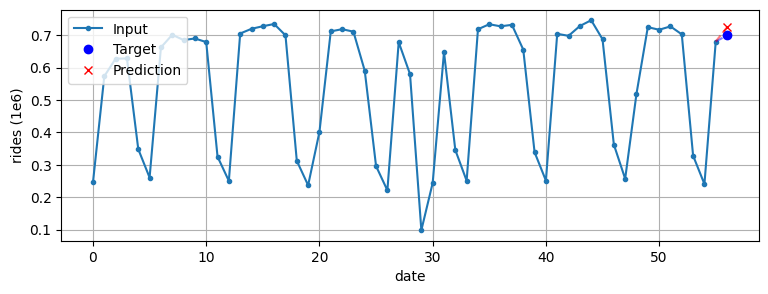

In [277]:
plot_window(X_valid_one[0], y_valid_one[0], y_pred[0])

And here is a comparative plot of predictions on the entire validation set.

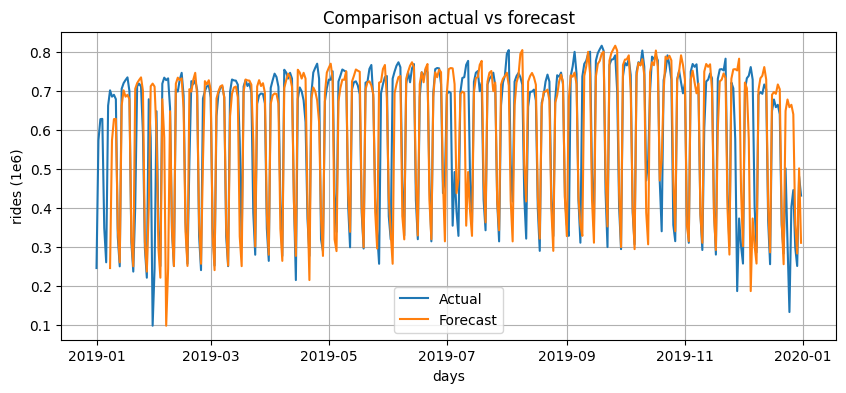

In [154]:
def plot_forecast(actual, forecast, future=False):
    plt.figure(figsize=(10, 4))


    # use future if actual and forecast end dates are shifted by a day
    if future:
        x_forecast = actual.index[-len(forecast)+1:].append(
            pd.DatetimeIndex([
                actual.index[-1] + pd.Timedelta(days=1)
            ])
        )
    # otherwise assume actual and forecast end dates are aligned
    else:
        x_forecast = actual.index[-len(forecast):]

    plt.plot(actual.index, actual, label="Actual")
    plt.plot(x_forecast, forecast, label="Forecast")
    plt.xlabel("days")
    plt.ylabel("rides (1e6)")
    plt.title("Comparison actual vs forecast")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_forecast(rail_valid, rail_valid.shift(7).iloc[7:])

Let's save the results for comparison later

In [155]:
# saving model stats for later
pred_one_models = {}
pred_one_models['naive']= {'model': "naive - d-7", "val_loss": val_loss}

#### Baseline 2: linear baseline

Our second basline model will be a linear regression. We can implement it using keras `Sequential` API by simply using a `Dense` layer with no activation functions.



##### TODO: Declare and train the linear model
 - write a linear regression model using a Dense layer
 - Don't forget to use `Flatten` and define the expected input shape using the keyword argument `input_shape`
 - Use the Adam optimizer with the default learning rate
 - Train it it for 20 epochs
 - Don't forget to include your validation data
 - Check the learning curves and the performance on the validation set


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

#TODO declare and train your model here
model = ...

model.compile(...)

history = model.fit(...)

In [156]:
#SOLUTION
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input([n_steps,1]),
    keras.layers.Flatten(),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train_one, y_train_one, epochs=20,
                    validation_data=(X_valid_one, y_valid_one))

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2681 - val_loss: 0.2218
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1925 - val_loss: 0.1750
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1502 - val_loss: 0.1354
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1155 - val_loss: 0.1037
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0884 - val_loss: 0.0799
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0683 - val_loss: 0.0627
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0540 - val_loss: 0.0506
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0440 - val_loss: 0.0423
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0371 - val_loss: 0.0367
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0324 - val_loss: 0.0328
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0291 - val_loss: 0.0300
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0268 - val_lo

In [157]:
# saving model stats for later
pred_one_models['linear']= {'model': model, 'history': history}

<Axes: >

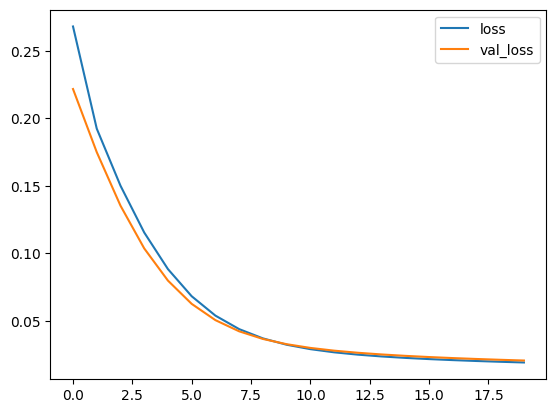

In [158]:
pd.DataFrame(history.history).plot()

In [159]:
model.evaluate(X_valid_one, y_valid_one)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0207 


0.02068813145160675

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


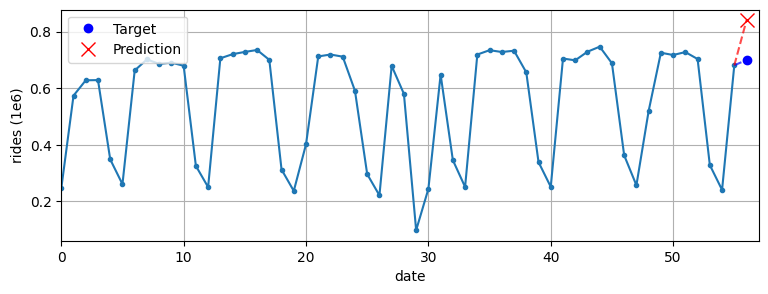

In [160]:
y_pred = model.predict(X_valid_one)
plot_window(X_valid_one[0, :, 0], y_valid_one[0, 0], y_pred[0, 0])

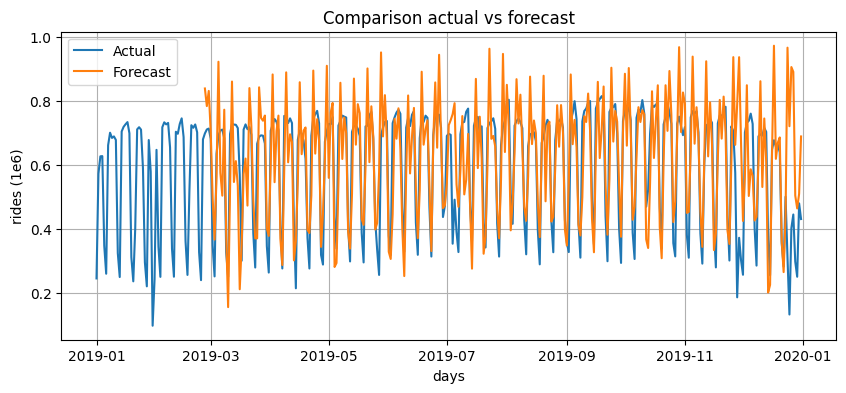

In [161]:
plot_forecast(rail_valid, y_pred[...])

### Classical forecasting baseline
So far our baselines only relied on recent observations.
A classical approach for forecasting time series is to explicitly model trend, autoregressive effects and seasonality. One such model is Seasonal ARIMA (SARIMA).

#### Baseline 3: SARIMA
Here we use a SARIMA model with a weekly seasonal period (7 days), which is particularly relevant for public transport ridership data.

Unlike the neural-network models above, SARIMA is trained directly on the time series rather than on sliding-window inputs.

In [86]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
#TODO
# Train a SARIMA model on the rail_train series
# Use:
#   order=(1, 0, 0)
#   seasonal_order=(0, 1, 1, 7)
#
# Then generate predictions for all dates in the validation period
# and compute the MSE.

In [162]:
#SOLUTION
sarima_model = ARIMA(
    rail_train,
    order=(1, 0, 0),
    seasonal_order=(0, 1, 1, 7)
)
# Fitting model parameters
sarima_results = sarima_model.fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [163]:
# Predicting on the validation set in order to evaluate the model
sarima_pred = sarima_results.forecast(steps=len(rail_valid))
# calculating MSE over the validation set
val_loss = np.mean(np.square(rail_valid.to_numpy() - sarima_pred.to_numpy()))
print(f"SARIMA validaiton MSE:{val_loss}")

SARIMA validaiton MSE:0.00996510857526973


Here is some code to visualise the results

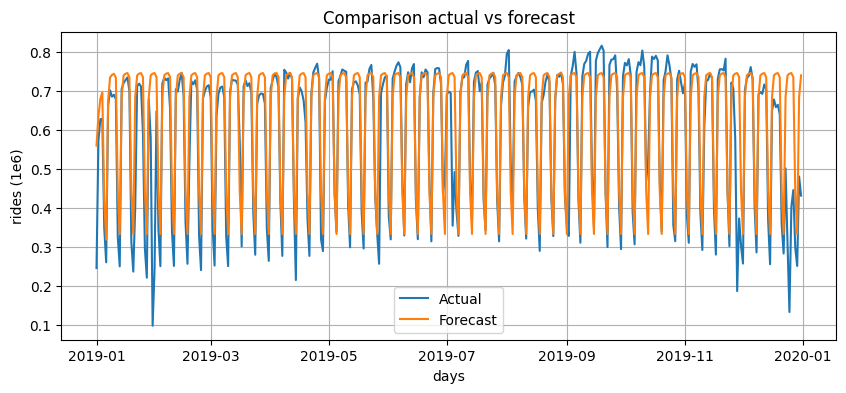

In [164]:
plot_forecast(rail_valid, sarima_pred)

Let's save the results for later comparison:

In [165]:
pred_one_models["SARIMA"] = {
    "model": sarima_results,
    "val_loss": val_loss
}

### Recurrent models

#### Model 1: Simple RNN
Our first recurrent model will use simple recurrent units. You can implement it using the built-in `keras.layers.SimpleRNN`.

Here again we will specify the expected input shape (ignoring the batch dimension). We want the time-steps dimension to be variable: thus we set it to `None`. The sequence element dimension continues to be 1.

##### TODO: train the simple RNN model
 - Use the Adam optimizer with the a learning rate of 0.02
 - Train it it for 20 epochs
 - Don't forget to include your validation data
 - Check the learning curves and the performance on the validation set

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input([None,1]),
    keras.layers.SimpleRNN(1)
])

#TODO train the model here


In [166]:
#SOLUTION
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input([None,1]),
    keras.layers.SimpleRNN(1)
])


model.compile(loss="mse", optimizer="adam")
model.optimizer.learning_rate = 2e-2
history = model.fit(X_train_one, y_train_one, epochs=20,
                    validation_data=(X_valid_one, y_valid_one))

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.6056 - val_loss: 0.2723
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2958 - val_loss: 0.2797
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4061 - val_loss: 0.4308
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.3031 - val_loss: 0.3261
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4550 - val_loss: 0.3776
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3081 - val_loss: 0.3335
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2478 - val_loss: 0.2457
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2493 - val_loss: 0.2385
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2495 - val_loss: 0.2396
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2481 - val_loss: 0.2224
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2529 - val_loss: 0.2344
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2

In [167]:
# saving model stats for later
pred_one_models['simpleRNN']= {'model': model, 'history': history}

<Axes: >

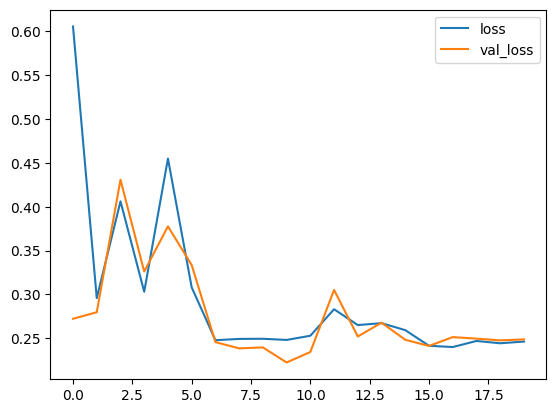

In [168]:
pd.DataFrame(history.history).plot()

In [169]:
model.evaluate(X_valid_one, y_valid_one)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2487 


0.2487441897392273

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


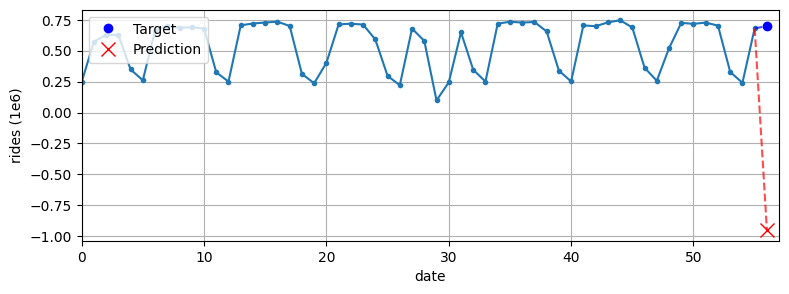

In [170]:
y_pred = model.predict(X_valid_one)
plot_window(X_valid_one[0, :, 0], y_valid_one[0, 0], y_pred[0, 0])
plt.show()

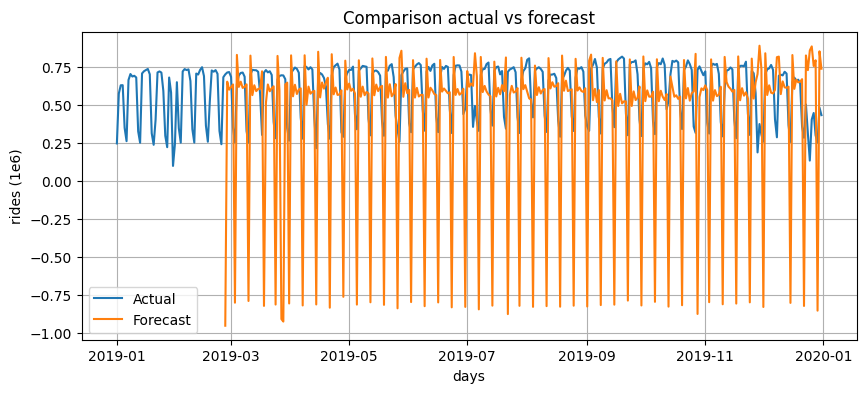

In [171]:
plot_forecast(rail_valid, y_pred[...])

#### Model 2: Deep simple RNN
This time we will use multiple recurrent layers in our model. The final output will be computed with a dense layer.


##### Chaining two RNN layers
Notice that while recurrent layers expect sequence inputs with 3 dimensions (samples, time, element size), they output by default 2 D data as in `[samples, predicted element size]`.

If you chain two RNN layers, the first one needs yield sequence-shaped outputs (with the 3 dimensions) so that it is compatible with the second layer. In this case, the layer needs to be declared with the keywork argument `return_sequences=True`.

##### TODO: Create and train a Deep RNN with 2 hidden recurrent layers
 - Use two simple RNN layers with 20 units
 - Compute the final output doing a linear read-out (use a Dense layer with no activation)
 - Use the Adam optimizer with the default learning rate
 - Train it it for 20 epochs
 - Don't forget to include your validation data
 - Check the learning curves and the performance on the validation set

In [130]:
np.random.seed(42)
tf.random.set_seed(42)

#TODO declare and train your model

In [172]:
#SOLUTION
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input([None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train_one, y_train_one, epochs=20,
                    validation_data=(X_valid_one, y_valid_one))

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0172 - val_loss: 0.0103
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0083 - val_loss: 0.0082
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0074 - val_loss: 0.0074
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0069 - val_loss: 0.0070
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0066 - val_loss: 0.0067
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0064 - val_loss: 0.0065
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0063 - val_loss: 0.0064
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0062 - val_loss: 0.0063
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0061 - val_loss: 0.0062
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0060 - val_loss: 0.0061
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0

In [173]:
# saving model stats for later
pred_one_models['DeepRNN']= {'model': model, 'history': history}

<Axes: >

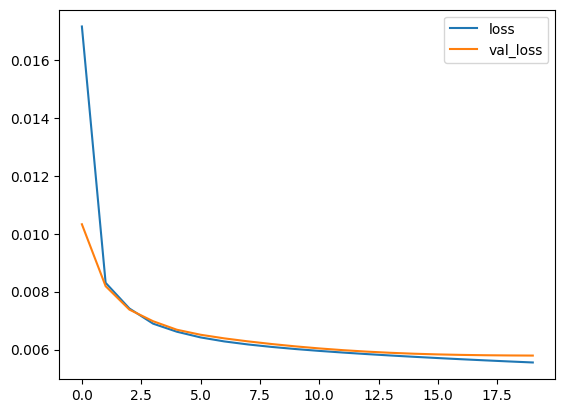

In [174]:
pd.DataFrame(history.history).plot()

In [175]:
model.evaluate(X_valid_one, y_valid_one)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0058


0.005791340954601765

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


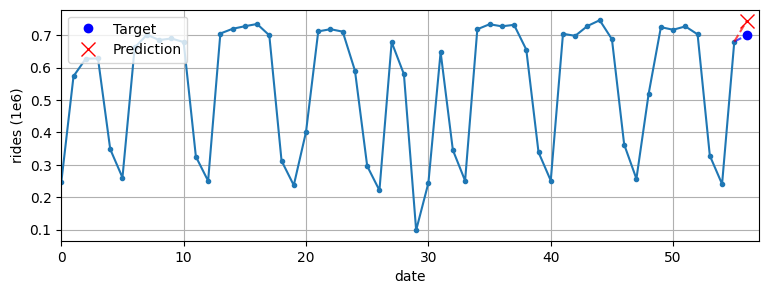

In [176]:
y_pred = model.predict(X_valid_one)
plot_window(X_valid_one[0, :, 0], y_valid_one[0, 0], y_pred[0, 0])

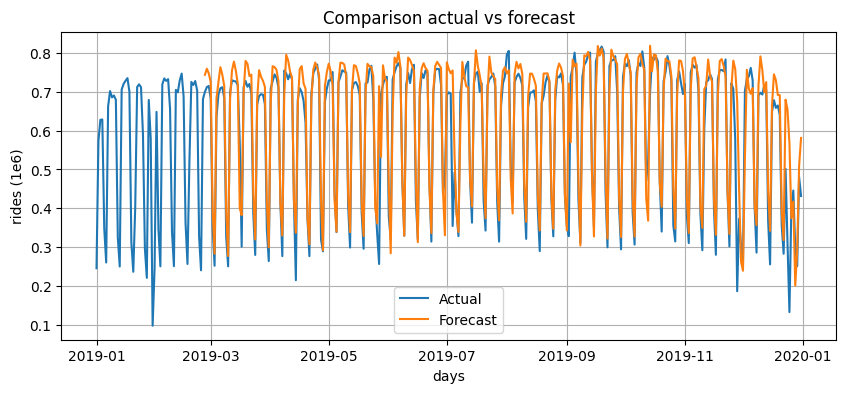

In [177]:
plot_forecast(rail_valid, y_pred[...])

### TODO: Final comparison and model choice
Compare the compare performances of different models in validation to pick the best model.
Apply it to the test set and evaluate it: is the performance close to what you got in the validation set?

In [ ]:
#TODO

In [178]:
pred_one_models

{'naive': {'model': 'naive - d-7',
  'val_loss': np.float64(0.011269848393841422)},
 'linear': {'model': <Sequential name=sequential_9, built=True>,
  'history': <keras.src.callbacks.history.History at 0x7eca8a3b3750>},
 'SARIMA': {'model': <statsmodels.tsa.arima.model.ARIMAResultsWrapper at 0x7eca8a3c7bb0>,
  'val_loss': np.float64(0.00996510857526973)},
 'simpleRNN': {'model': <Sequential name=sequential_10, built=True>,
  'history': <keras.src.callbacks.history.History at 0x7eca9f0972f0>},
 'DeepRNN': {'model': <Sequential name=sequential_11, built=True>,
  'history': <keras.src.callbacks.history.History at 0x7eca9f0bfa70>}}

In [195]:
#SOLUTION
data = []
for estim, log in pred_one_models.items():
    try:
        val_loss = log['history'].history['val_loss'][-1]
    except:
        val_loss = log['val_loss']
    data.append({'Model': estim,
                'Validation loss': val_loss})
df = pd.DataFrame(data)
display(df)
best_model = df.loc[df["Validation loss"].idxmin(), "Model"]
display(f'Best: {best_model}')

,Model,Validation loss
0,naive,0.011270
1,linear,0.020688
2,SARIMA,0.009965
3,simpleRNN,0.248744
4,DeepRNN,0.005791


'Best: DeepRNN'

#SOLUTION
You need to inspect the validation results table above and select the model with lowest error.


**In this run: best model was the deep RNN**
Here is it's performance on the test set.

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0373


0.03726290538907051

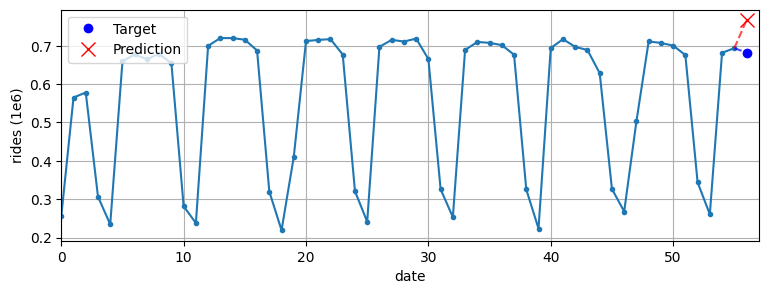

In [196]:
#SOLUTION if a keras model wins
model = pred_one_models[best_model]['model']
y_pred = model.predict(X_test_one)
plot_window(X_test_one[0, :, 0], y_test_one[0, 0], y_pred[0, 0])
model.evaluate(X_test_one, y_test_one)

In [199]:
# SOLUTION if SARIMA wins
# SARIMA is cheap to retrain on train + valid
sarima_retrain = ARIMA(
    pd.concat([rail_train, rail_valid]),
    order=(1, 0, 0),
    seasonal_order=(0, 1, 1, 7)
)
sarima_results = sarima_retrain.fit()

y_pred = sarima_results.forecast(steps=len(rail_test))

test_loss = np.mean(np.square(rail_test.to_numpy() - y_pred.to_numpy()))

test_loss

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


np.float64(0.1961748187122977)

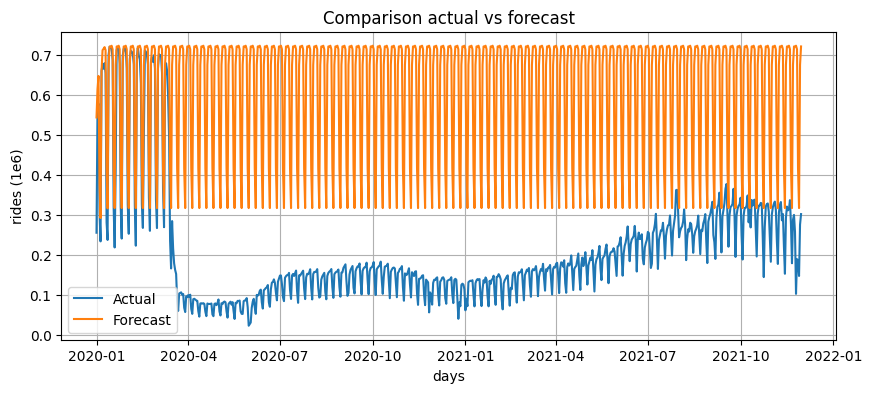

In [198]:
#SOLUTION
plot_forecast(rail_test, y_pred[...])

## Prediction task 2: forecast multiple time steps

We now want to predict the next 14 days instead of only the next day.

We will compare three approaches:

1. **Recursive forecasting**: repeatedly apply a one-step model.
2. **Direct forecasting (Seq2Vec)**: predict all 14 days at once.
3. **Seq2Seq forecasting**: predict a 14-day horizon at every input time step.

The three methods use different target representations and produce different output shapes.
| Method    | Training Target shape | Output shape                  | Evaluation target shape |
|-----------|-----------------------|-------------------------------|-------------------------|
| Recursive | [batch, 1]            | [batch, 1] repeatedly applied | [batch, 14]             |
| Seq2Vec   | [batch, 14]           | [batch, 14]                   | [batch, 14]             |
| Seq2Seq   | [batch, 56, 14]       | [batch, 56, 14]               | [batch, 56, 14]         |

#### Why compare different methods ?
These methods illustrate a common trade-off in forecasting:

- Recursive forecasting reuses a simple one-step model but may accumulate prediction errors.
- Seq2Vec forecasting predicts the whole horizon directly.
- Seq2Seq forecasting provides more training signals by producing predictions at every time step.


### Method 1: Recursive forecasting with a one-step model


We'll reuse the one-step forecasting model trained earlier and apply it recursively to predict the next 14 days.

<div class="alert alert-info">
💡This approach is attractive because we can <b>reuse an already-trained one-step model</b> without changing its architecture.
</div>

In [297]:
ahead = 14

X = X_valid_one.copy()
model = pred_one_models['DeepRNN']['model']
for step_ahead in range(ahead):
    y_pred_one = model.predict(X)[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, -ahead:, 0]

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [285]:
Y_pred.shape

(309, 14)

#### Evaluation targets for recursive forecasting

To evaluate a 14-day recursive forecast, we need the true 14 future observations associated with each validation window.

These targets are only used for evaluation. They are not used to train the one-step model.

In [298]:
# Build the true 14-day future horizon associated with each
# validation window.

n_valid_recursive = len(X_valid_one) - ahead + 1

Y_valid_recursive = np.column_stack([
    rail_valid.to_numpy()[n_steps + step_ahead :
                          n_steps + step_ahead + n_valid_recursive]
    for step_ahead in range(ahead)
])

Y_valid_recursive.shape

(296, 14)

#### TODO: check the loss value (MSE) for this method

In [ ]:
#TODO

In [300]:
#SOLUTION
np.mean(np.square(Y_valid_recursive, Y_pred[:n_valid_recursive]))

np.float64(0.4093583469007785)

You can still use `plot_window` and `plot_forecast` to visualize results.

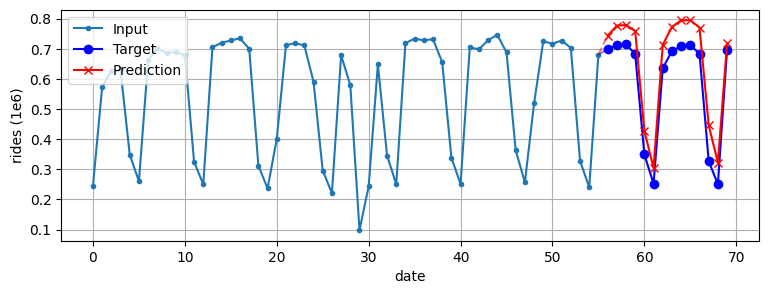

In [288]:
plot_window(
    X_valid_one[0],
    Y_valid_recursive[0],
    Y_pred[0]
)

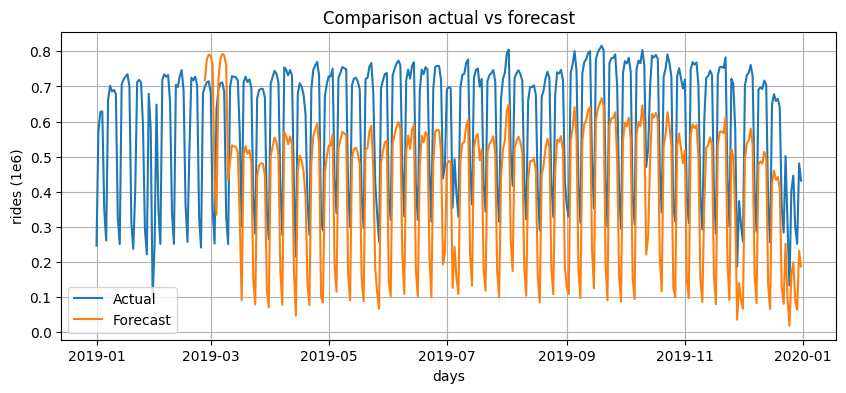

In [290]:
plot_forecast(rail_valid, Y_pred[...,-1])

#### TODO: Baselines: naive and linear prediction

Implement the naive and the linear baselines folowing this method to predict the next 14 steps. Compare their performances to the previous RNN model.

In [309]:
Y_pred_naive.shape, Y_valid_recursive.shape

((309, 14, 1), (296, 14))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Naive Baseline MSE: 0.010352144621705356
Linear Baseline MSE: 0.017102668885831396
DRNN Model MSE: 0.04247952701298095


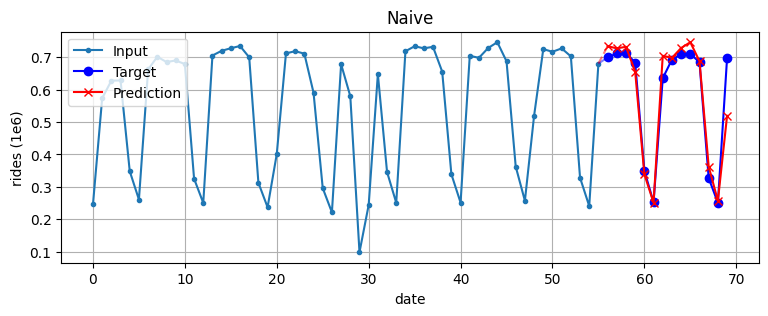

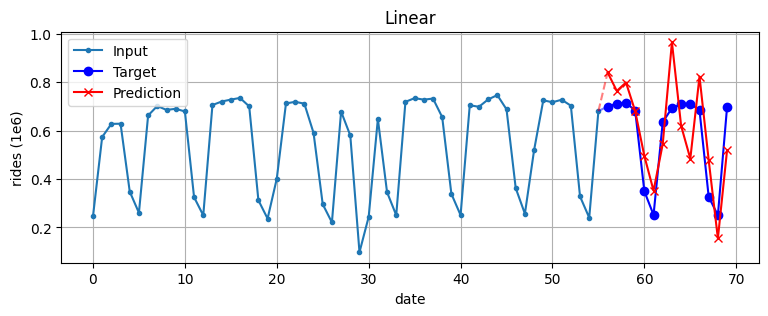

In [311]:
#SOLUTION
# Naive:
# take from t-7-ahead until t-7 for each sample

Y_pred_naive = X_valid_one[:, -7-ahead: -7].squeeze()

# # Use the model to predict the next 14 steps
# Linear
X = X_valid_one.copy()
model_lin = pred_one_models['linear']['model']

for step_ahead in range(ahead):
    y_pred_one = model_lin.predict(X[:,-56:,:])[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)
Y_pred_linear = X[:, -ahead:, 0]

mse_naive = np.mean(np.square(Y_valid_recursive - Y_pred_naive[:n_valid_recursive]))
mse_linear = np.mean(np.square(Y_valid_recursive - Y_pred_linear[:n_valid_recursive]))
mse_drnn = np.mean(np.square(Y_valid_recursive - Y_pred[:n_valid_recursive])) # Y_pred from the previous RNN prediction

print(f"Naive Baseline MSE: {mse_naive}")
print(f"Linear Baseline MSE: {mse_linear}")
print(f"DRNN Model MSE: {mse_drnn}")

idx = 0
plot_window(X_valid_one[idx], Y_valid_recursive[idx], Y_pred_naive[idx])
plt.title("Naive")
plt.show()

plot_window(X_valid_one[idx], Y_valid_recursive[idx], Y_pred_linear[idx])
plt.title("Linear")
plt.show()


### Method 2A: Predicting 14 steps at once at the end (seq2vec)

In this section the model processes the entire input sequence before producing a single output vector containing all 14 future predictions.

This remains a sequence-to-vector task because only a single output is produced after processing the whole input sequence.

<div class="alert alert-info">
⏱️Unlike recursive forecasting, all 14 future values are predicted in a single forward pass.
</div>

#### Framing data and targets for multi-step forecasting

For the remaining methods, each input window is paired with the next 14 days:

Input:
[t−55, ..., t]

Target:
[t+1, ..., t+14]

This target representation allows the model to learn the entire forecasting horizon directly.

In [313]:
ahead = 14

def make_multi_step_windows(series, window=56, horizon=14):
    arr = series.to_numpy()

    X = []
    Y = []

    for i in range(len(arr) - window - horizon + 1):
        X.append(arr[i:i+window])
        Y.append(arr[i+window:i+window+horizon])

    return np.array(X)[..., np.newaxis], np.array(Y)


In [314]:
X_train_multi, Y_train_multi = make_multi_step_windows(
    rail_train,
    window=n_steps,
    horizon=ahead
)

X_valid_multi, Y_valid_multi = make_multi_step_windows(
    rail_valid,
    window=n_steps,
    horizon=ahead
)

X_test_multi, Y_test_multi = make_multi_step_windows(
    rail_test,
    window=n_steps,
    horizon=ahead
)

#### Naive prediction
Here we apply the same naive method as before to obtain predictions.

In [315]:
# take the t-7-ahead until t-7
# shape should be (n_samples, ahead)
Y_naive_pred = X_valid_multi[:, -7-ahead:-7].squeeze()
val_loss = np.mean(keras.metrics.mse(Y_valid_multi, Y_naive_pred))
val_loss

np.float64(0.010352144621705356)

#### Linear model

In [316]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input([n_steps, 1]),
    keras.layers.Flatten(),
    keras.layers.Dense(ahead)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train_multi, Y_train_multi, epochs=20,
                    validation_data=(X_valid_multi, Y_valid_multi))

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3488 - val_loss: 0.1005
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0664 - val_loss: 0.0498
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0466 - val_loss: 0.0439
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0414 - val_loss: 0.0390
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0371 - val_loss: 0.0350
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0336 - val_loss: 0.0317
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0307 - val_loss: 0.0289
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0282 - val_loss: 0.0266
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0262 - val_loss: 0.0247
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0244 - val_loss: 0.0231
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0230 - val_loss: 0.0217
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0217 - val_lo

In [317]:
# saving model stats for later
pred_multi_models = {}
pred_multi_models['linear']= {'model': model, 'history': history}

<Axes: >

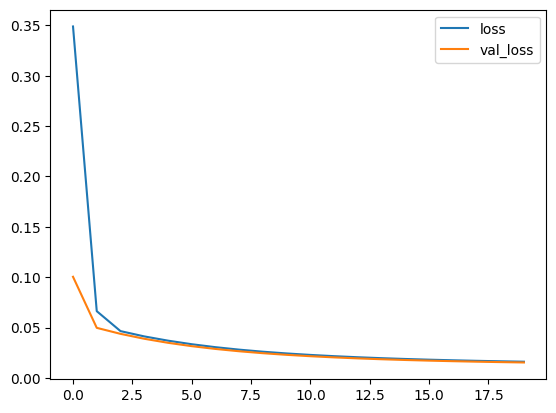

In [318]:
pd.DataFrame(history.history).plot()

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step


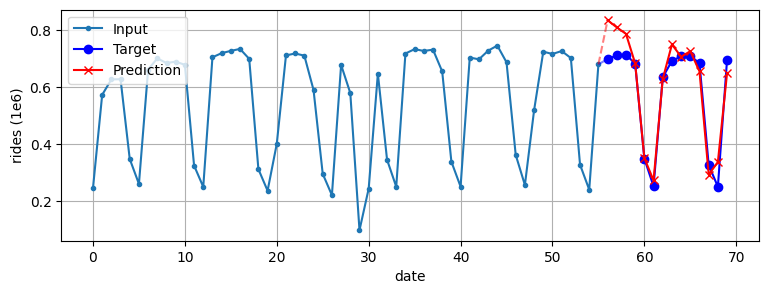

In [324]:
Y_pred_multi = model.predict(X_valid_multi)
idx = 0
plot_window(X_valid_multi[idx], Y_valid_multi[idx], Y_pred_multi[idx])

#### Model 1: Deep simple RNN with output prediction at the end

Let's create an RNN that predicts all 14 next values at once. To do that, all you need is to change the size of the final `Dense` layer to 14.

##### TODO: build and train the new RNN model with output size = 14
- Use two simple RNN layers with 20 units
- Compute the final output doing a linear read-out (use a Dense layer with no activation)
- Use the Adam optimizer with the default learning rate
- Train it it for 20 epochs
- Don't forget to include your validation data
- Check the learning curves and the performance on the validation set

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

#TODO declare and train your model here



In [337]:
#SOLUTION
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(ahead)
])


model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train_multi, Y_train_multi, epochs=20,
                    validation_data=(X_valid_multi, Y_valid_multi))

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.2849 - val_loss: 0.0573
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0371 - val_loss: 0.0299
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0290 - val_loss: 0.0280
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0275 - val_loss: 0.0265
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0259 - val_loss: 0.0248
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0242 - val_loss: 0.0232
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0225 - val_loss: 0.0217
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0210 - val_loss: 0.0203
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0196 - val_loss: 0.0190
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0183 - val_loss: 0.0179
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0172 - val_loss: 0.0169
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0163 - val_l

In [338]:
# saving model stats for later
pred_multi_models['DeepRNN_seq2vec']= {'model': model, 'history': history}

<Axes: >

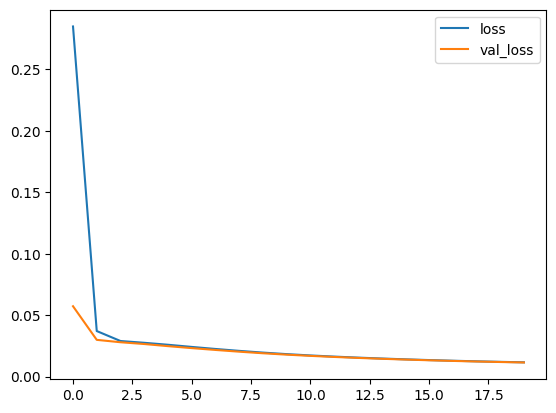

In [339]:
pd.DataFrame(history.history).plot()

In [340]:
model.evaluate(X_valid_multi, Y_valid_multi)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0115


0.011522708460688591

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


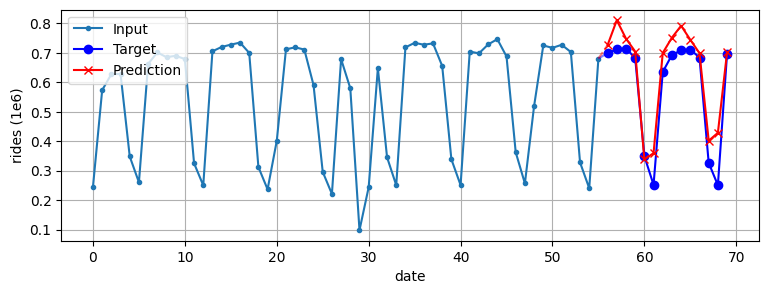

In [341]:
Y_pred_multi = model.predict(X_valid_multi)
idx = 0
plot_window(X_valid_multi[idx], Y_valid_multi[idx], Y_pred_multi[idx])

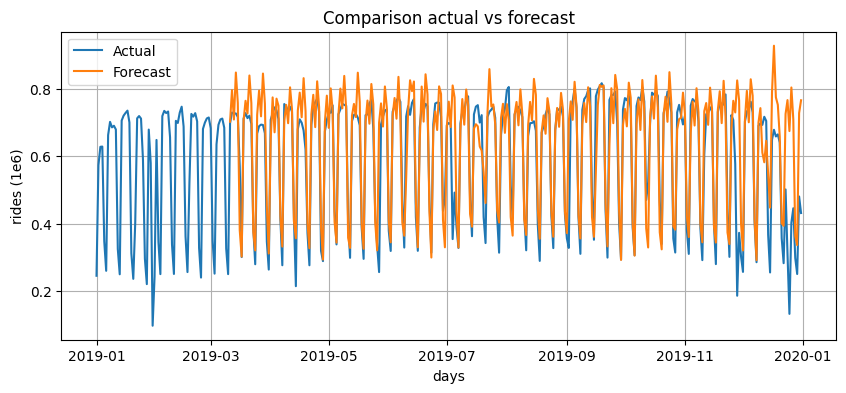

In [342]:
plot_forecast(rail_valid, Y_pred_multi[...,-1])

### Method 2B: Sequence-to-Sequence Forecasting (Seq2Seq)

Now let's create RNN models that predict the next 14 steps at each time step.

This means that at t=0, the model predicts a vector containing the next 14 time steps.
Then at t=1, it predicts another vector containing the next 14 future time steps.
A crucial difference here is that for each time step we expect a prediction, while before we only cared about the last output.
This implies that the loss will contain a term for each time step, not just the last.
This way, during backpropagation, each time step contributes directly to the loss.
As a result, gradients originate from many output locations instead of only the final one.
In practice, this often provides a stronger training signal and may **stabilize or accelerate training**.



**Note:** In this model and all others used here, predictions for time $T$ only take into account past series values, i.e. where $t < T$. This defines them as a *causal* models.

#### Framing seq2seq data and prediction targets
Instead of generating a single 14-day forecast at the end of the sequence, we generate a 14-day forecast at every time step.

Example for `ahead=3`:

```
Input window

x1 x2 x3 x4 x5 ...

Targets

at t=1 -> [x2 x3 x4]
at t=2 -> [x3 x4 x5]
at t=3 -> [x4 x5 x6]
...
```
This is why the target tensor now has three dimensions:
`[batch size, sequence length, forecast horizon]`.

In [343]:
def make_seq2seq_windows(series, window=56, horizon=14):
    arr = series.to_numpy()
    X = []
    Y = []
    for start in range(len(arr) - window - horizon + 1):
        x = arr[start:start+window]
        target = np.zeros((window, horizon))
        for t in range(window):
            for h in range(horizon):
                idx = start + t + h + 1
                target[t, h] = arr[idx]
        X.append(x)
        Y.append(target)

    return np.array(X)[..., np.newaxis], np.array(Y)

X_train_seq, Y_train_seq = make_seq2seq_windows(
    rail_train,
    window=n_steps,
    horizon=ahead
)

X_valid_seq, Y_valid_seq = make_seq2seq_windows(
    rail_valid,
    window=n_steps,
    horizon=ahead
)

X_test_seq, Y_test_seq = make_seq2seq_windows(
    rail_test,
    window=n_steps,
    horizon=ahead
)

In [344]:
X_train_seq.shape, Y_train_seq.shape

((1027, 56, 1), (1027, 56, 14))

#### Custom evaluation metric function

All outputs are needed during training, but only the output at the last time step is useful at inference time for predictions and evaluation.
So even though we will rely on the MSE over all the outputs for training, we will use a custom metric for evaluation, to compute MSE only over the output at the last time step:

In [345]:
def last_time_step_mse(Y_true, Y_pred):
    return keras.metrics.mse(Y_true[:, -1], Y_pred[:, -1])

#### TODO Model 2: Deep simple RNN with output prediction at every timestep
- Use two simple RNN layers with 20 units
- Compute the final output doing a linear read-out (use a Dense layer with no activation)
- Use the Adam optimizer with 0.01 learning rate
- Train it it for 20 epochs
- Don't forget to include your validation data
- Check the learning curves and the performance on the validation set

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

#TODO

In [346]:
#SOLUTION
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input([None,1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(ahead))
])

model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.01), metrics=[last_time_step_mse])
history = model.fit(X_train_seq, Y_train_seq, epochs=20,
                    validation_data=(X_valid_seq, Y_valid_seq))

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - last_time_step_mse: 0.0908 - loss: 0.0932 - val_last_time_step_mse: 0.0229 - val_loss: 0.0255
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - last_time_step_mse: 0.0170 - loss: 0.0195 - val_last_time_step_mse: 0.0129 - val_loss: 0.0151
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - last_time_step_mse: 0.0118 - loss: 0.0138 - val_last_time_step_mse: 0.0108 - val_loss: 0.0126
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - last_time_step_mse: 0.0101 - loss: 0.0119 - val_last_time_step_mse: 0.0095 - val_loss: 0.0111
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - last_time_step_mse: 0.0092 - loss: 0.0108 - val_last_time_step_mse: 0.0089 - val_loss: 0.0103
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - last_time_step_mse: 0.0087 - loss: 0.0102 - val_last_time_step_mse: 0.0088 - val_loss: 0.0100
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - last_time_step_mse: 0.0086 - loss: 0.0099 - val_last_time_step_ms

In [347]:
# saving model stats for later
pred_multi_models['DeepRNN_seq2seq']= {'model': model, 'history': history}

<Axes: >

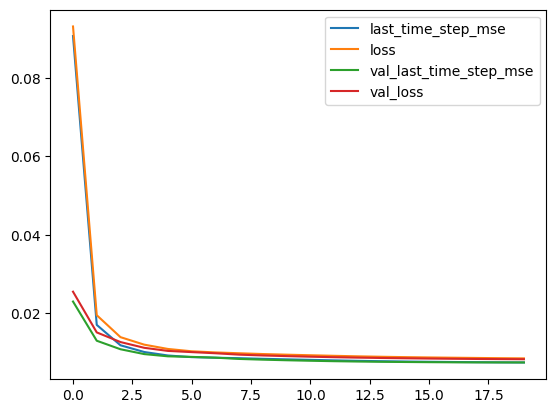

In [348]:
pd.DataFrame(history.history).plot()

In [349]:
model.evaluate(X_valid_seq, Y_valid_seq)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - last_time_step_mse: 0.0074 - loss: 0.0082


[0.00820494070649147, 0.007382378447800875]

##### Plot multiple forecasts with the new shaped output




**Attention** Now we have outputs at every time steps, the shape of the array of predictions is different!

In [350]:
Y_pred_seq = model.predict(X_valid_seq)
Y_pred_seq.shape, Y_valid_seq.shape

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step


((296, 56, 14), (296, 56, 14))


You can reuse the previous functions if you call them like this:



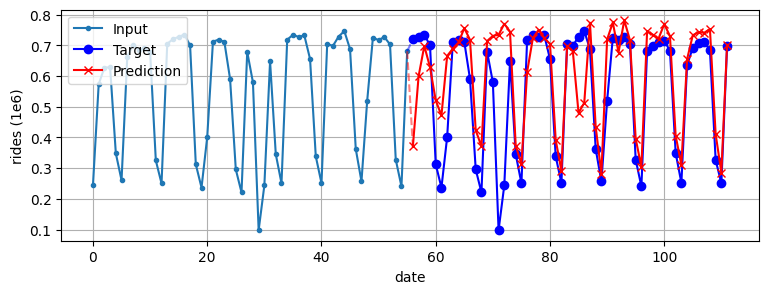

<Figure size 640x480 with 0 Axes>

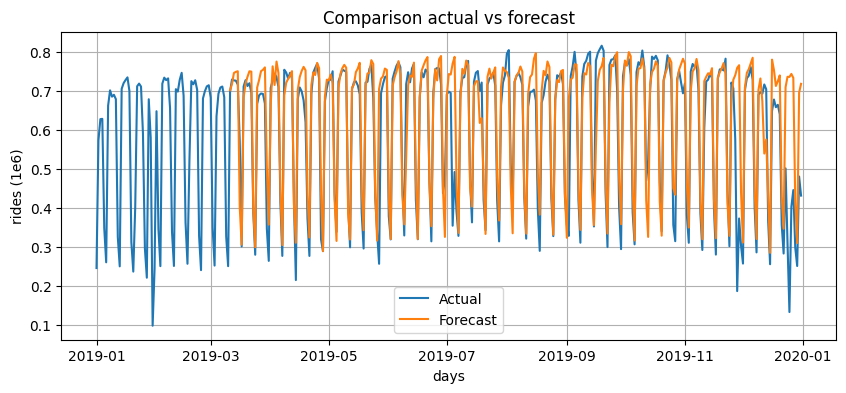

In [357]:
idx=0
plot_window(X_valid_seq[0], Y_valid_seq[0,...,-1], Y_pred_seq[0,...,-1])
plt.figure()
plot_forecast(rail_valid, Y_pred_seq[:,-1,-1])

#### TODO Model 3: Deep LSTM with output prediction at every timestep

- Use two LSTM layers with 20 units
- Compute the final output doing a linear read-out (use a Dense layer with no activation)
- Use the Adam optimizer with the default learning rate
- Train it it for 20 epochs
- Don't forget to include your validation data
- Check the learning curves and the performance on the validation set

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

#TODO

In [358]:
#SOLUTION
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(ahead))
])

# Training the model

model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.01), metrics=[last_time_step_mse])
history = model.fit(X_train_seq, Y_train_seq, epochs=20,
                    validation_data=(X_valid_seq, Y_valid_seq))


Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - last_time_step_mse: 0.0683 - loss: 0.0766 - val_last_time_step_mse: 0.0329 - val_loss: 0.0359
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - last_time_step_mse: 0.0327 - loss: 0.0348 - val_last_time_step_mse: 0.0324 - val_loss: 0.0340
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - last_time_step_mse: 0.0320 - loss: 0.0330 - val_last_time_step_mse: 0.0312 - val_loss: 0.0321
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - last_time_step_mse: 0.0269 - loss: 0.0279 - val_last_time_step_mse: 0.0211 - val_loss: 0.0223
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - last_time_step_mse: 0.0169 - loss: 0.0183 - val_last_time_step_mse: 0.0154 - val_loss: 0.0163
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - last_time_step_mse: 0.0140 - loss: 0.0152 - val_last_time_step_mse: 0.0143 - val_loss: 0.0149
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - last_time_step_mse: 0.0116 - loss: 0.0129 - val_last_time_step_mse: 0.0115 -

In [359]:
# saving model stats for later
pred_multi_models['DeepRNN_LSTM']= {'model': model, 'history': history}

<Axes: >

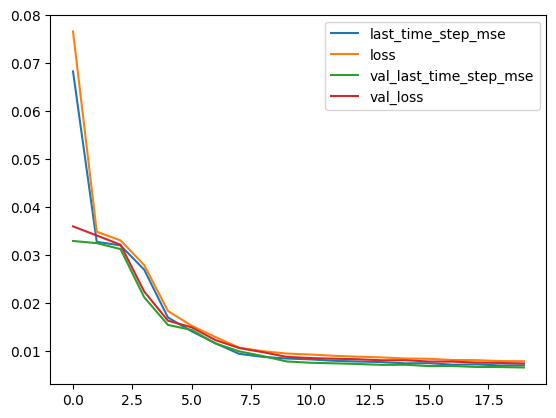

In [360]:
pd.DataFrame(history.history).plot()

In [361]:
model.evaluate(X_valid_seq, Y_valid_seq)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - last_time_step_mse: 0.0065 - loss: 0.0073


[0.007338179741054773, 0.0065069617703557014]

In [362]:
Y_pred_seq = model.predict(X_valid_seq)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step


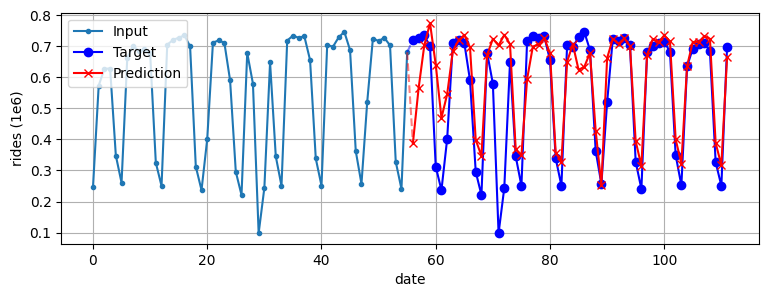

<Figure size 640x480 with 0 Axes>

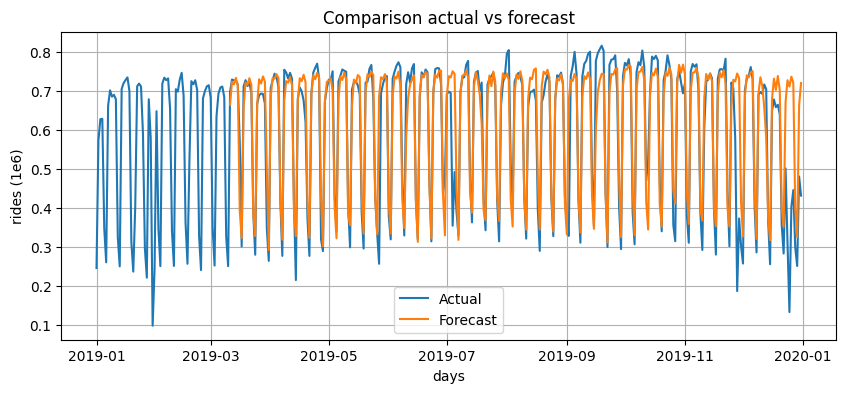

In [363]:
idx=0
plot_window(X_valid_seq[0], Y_valid_seq[0,...,-1], Y_pred_seq[0,...,-1])
plt.figure()
plot_forecast(rail_valid, Y_pred_seq[:,-1,-1])

#### TODO Model 4: Deep GRU with output prediction at every timestep
- Use two GRU layers with 20 units
- Compute the final output doing a linear read-out (use a Dense layer with no activation)
- Use the Adam optimizer with the default learning rate
- Train it it for 20 epochs
- Don't forget to include your validation data
- Check the learning curves and the performance on the validation set

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

#TODO

In [364]:
#SOLUTION
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.GRU(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(ahead))
])

# Training the model

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train_seq, Y_train_seq, epochs=20,
                    validation_data=(X_valid_seq, Y_valid_seq))

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - last_time_step_mse: 0.2797 - loss: 0.2871 - val_last_time_step_mse: 0.0894 - val_loss: 0.0999
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - last_time_step_mse: 0.0455 - loss: 0.0544 - val_last_time_step_mse: 0.0346 - val_loss: 0.0411
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - last_time_step_mse: 0.0317 - loss: 0.0389 - val_last_time_step_mse: 0.0321 - val_loss: 0.0378
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - last_time_step_mse: 0.0310 - loss: 0.0368 - val_last_time_step_mse: 0.0317 - val_loss: 0.0364
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - last_time_step_mse: 0.0305 - loss: 0.0355 - val_last_time_step_mse: 0.0312 - val_loss: 0.0352
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - last_time_step_mse: 0.0301 - loss: 0.0343 - val_last_time_step_mse: 0.0307 - val_loss: 0.0341
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - last_time_step_mse: 0.0296 - loss: 0.0332 - val_last_time_step_mse: 0.0300 

In [365]:
# saving model stats for later
pred_multi_models['DeepRNN_GRU']= {'model': model, 'history': history}

<Axes: >

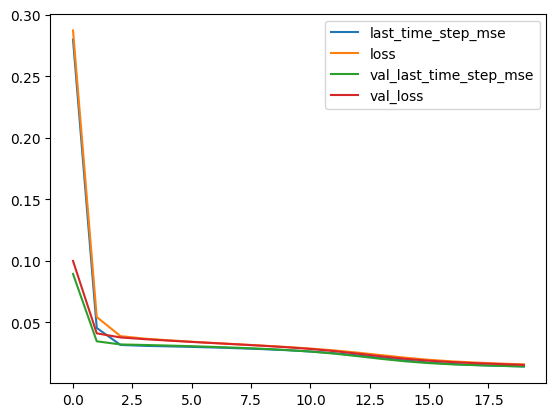

In [366]:
pd.DataFrame(history.history).plot()

In [367]:
model.evaluate(X_valid_seq, Y_valid_seq)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - last_time_step_mse: 0.0142 - loss: 0.0155


[0.015464676544070244, 0.014192530885338783]

In [368]:
Y_pred_seq = model.predict(X_valid_seq)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step


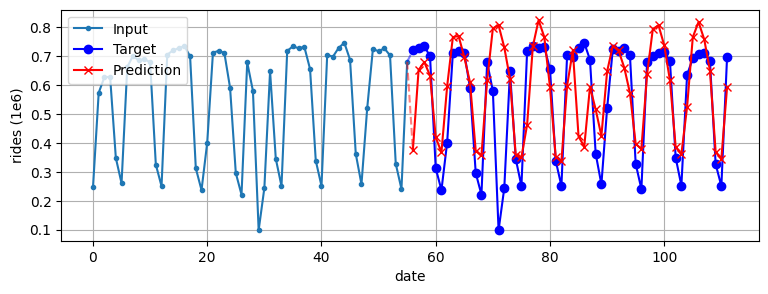

<Figure size 640x480 with 0 Axes>

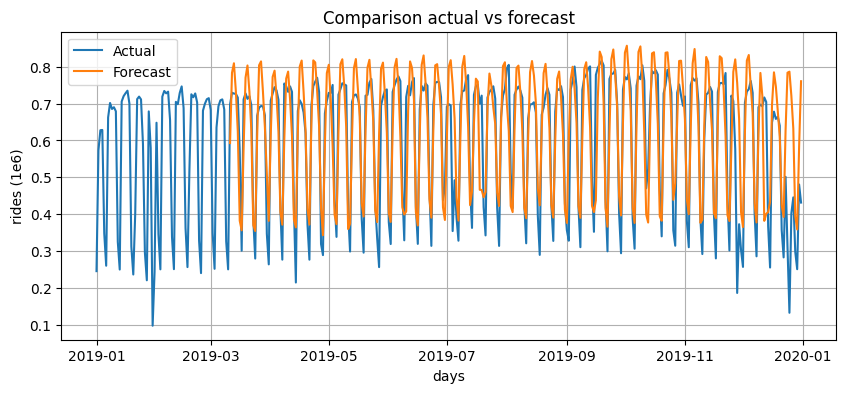

In [369]:
idx=0
plot_window(X_valid_seq[0], Y_valid_seq[0,...,-1], Y_pred_seq[0,...,-1])
plt.figure()
plot_forecast(rail_valid, Y_pred_seq[:,-1,-1])

### TODO: Model comparison for prediction task 2

Create a summary table with the validation performaces of all models used in this second task. Choose the best of them and evaluate it on the test set. Did it generalize as well as predicted by the validation score?

In [370]:
#SOLUTION
data = []
for estim, log in pred_multi_models.items():
    try:
        val_loss = log['history'].history['last_time_step_mse'][-1]
    except KeyError:
        val_loss = log['history'].history['val_loss'][-1]

    data.append({'Model': estim,
                'Validation loss': val_loss})
pd.DataFrame(data)

,Model,Validation loss
0,linear,0.015473
1,DeepRNN_seq2vec,0.011523
2,DeepRNN_seq2seq,0.007377
3,DeepRNN_LSTM,0.006956
4,DeepRNN_GRU,0.014227


`#SOLUTION`

**Best model was the deep RNN with LSTM layers**
Here is it's performance on the test set.

In [ ]:
#TODO Complete with the best model
model = pred_multi_models[...]['model']
display(model.evaluate(X_test_seq, Y_test_seq))

Y_pred_seq = model.predict(X_test_seq)
idx=0
plot_window(X_valid_seq[0], Y_valid_seq[0,...,-1], Y_pred_seq[0,...,-1])
plt.figure()
plot_forecast(rail_valid, Y_pred_seq[:,-1,-1])

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - last_time_step_mse: 0.0859 - loss: 0.0953


[0.09528087824583054, 0.08590308576822281]

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step


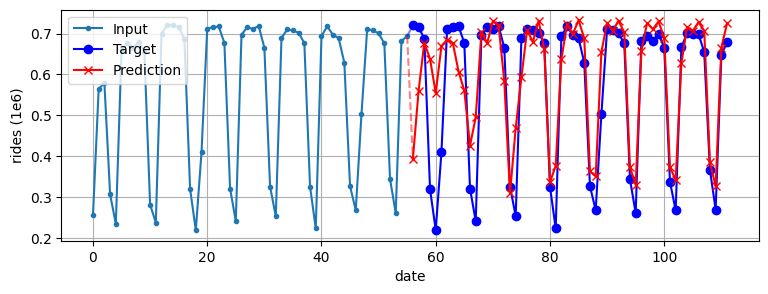

<Figure size 640x480 with 0 Axes>

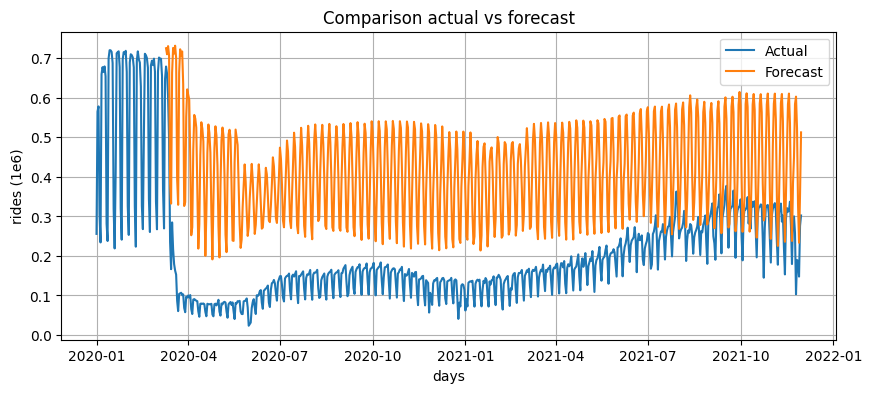

In [372]:
#SOLUTION
model = pred_multi_models['DeepRNN_LSTM']['model']
display(model.evaluate(X_test_seq, Y_test_seq))

Y_pred_seq = model.predict(X_test_seq)
idx=0
plot_window(X_test_seq[0], Y_test_seq[0,...,-1], Y_pred_seq[0,...,-1])
plt.figure()
plot_forecast(rail_test, Y_pred_seq[:,-1,-1])

## Extra models

Convolutional architectures offer an alternative to recurrent networks for processing sequential data.

### Why explore convolutional models?

| Architecture | Main idea | Potential advantages |
|--------------|------------|----------------------|
| CNN + GRU | Use convolutions to extract local patterns before recurrent processing | Faster training, shorter sequences after subsampling, local pattern extraction |
| WaveNet | Replace recurrence by stacks of causal dilated convolutions | Fully parallel training, easier optimization, large temporal receptive field |

The goal of this section is not necessarily to obtain the best forecasting performance, but to discover alternative sequence-processing architectures and compare their behavior with RNN-based models.

### Why explore convolutional models?
In short: faster training and often easier optimization than pure recurrent models.

| Aspect | CNN + GRU | WaveNet |
|---------|---------|---------|
| Main idea | CNN for short-term patterns, GRU for longer-term dependencies | Stacks of causal dilated convolutions instead of recurrent layers |
| Training | Convolutions process many time steps in parallel and reduce the amount of recurrent computation | No recurrence → fully parallel during training |
| Strengths | Local pattern extraction and efficient processing of long sequences | Large temporal context, easier optimization, parallel training |
| Motivation | Combine the strengths of CNNs and RNNs | Explore a modern non-recurrent alternative to RNNs |

The goal of this section is not necessarily to obtain the best forecasting performance, but to discover alternative sequence-processing architectures and compare their behavior with RNN-based models.

We will use the **seq2seq** data framing:

In [373]:
X_train = X_train_seq
Y_train = Y_train_seq

X_valid = X_valid_seq
Y_valid = Y_valid_seq

X_test = X_test_seq
Y_test = Y_test_seq

#### Model 5: 1D convolution + GRUs

##### Why use a 1D convolution?

RNNs process one time step after another, which can make training relatively slow.

A 1D convolution can efficiently detect short-term temporal patterns such as local trends, peaks or weekly variations while taking advantage of highly optimized parallel implementations on modern hardware.

Combining a convolutional layer with recurrent layers often reduces training time and improves convergence by providing higher-level temporal features to the RNN.



**Attention** Due to using a convolution stride of 2, the convolutional layer subsamples the input series by a factor of 2. That means that the predicted outputs will be related to the prediction targets with a similar subsampling factor.

Additionally, the kernel size of 4 in combination with using a valid convolution makes that the first predicted output corresponds to the 4th time-steps.

This means you should compare your predictions to a cropped and subsampled version of the targets array, as follows:
```
subsampled_target = target[:, 3::2]
```

##### TODO: train the conv + GRU model
 - Use the Adam optimizer with the default learning rate
 - Train it it for 20 epochs
 - Don't forget to include your validation data
 - Check the learning curves and the performance on the validation set




In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Conv1D(filters=20, kernel_size=4, strides=2, padding="valid",
                        input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(ahead))
])

#TODO train the model

In [374]:
#SOLUTION

np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input([None, 1]),
    keras.layers.Conv1D(filters=20, kernel_size=4, strides=2, padding="valid"),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(ahead))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train[:, 3::2], epochs=20,
                    validation_data=(X_valid, Y_valid[:, 3::2]))

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - last_time_step_mse: 0.2745 - loss: 0.2838 - val_last_time_step_mse: 0.1093 - val_loss: 0.1193
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - last_time_step_mse: 0.0561 - loss: 0.0678 - val_last_time_step_mse: 0.0343 - val_loss: 0.0421
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - last_time_step_mse: 0.0322 - loss: 0.0395 - val_last_time_step_mse: 0.0323 - val_loss: 0.0375
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - last_time_step_mse: 0.0312 - loss: 0.0359 - val_last_time_step_mse: 0.0316 - val_loss: 0.0350
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - last_time_step_mse: 0.0304 - loss: 0.0334 - val_last_time_step_mse: 0.0305 - val_loss: 0.0327
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - last_time_step_mse: 0.0292 - loss: 0.0311 - val_last_time_step_mse: 0.0289 - val_loss: 0.0304
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - last_time_step_mse: 0.0274 - loss: 0.0286 - val_last_time_step_ms

In [375]:
# saving model stats for later
extra_models = {}
extra_models['DeepRNN_CNN']= {'model': model, 'history': history}

<Axes: >

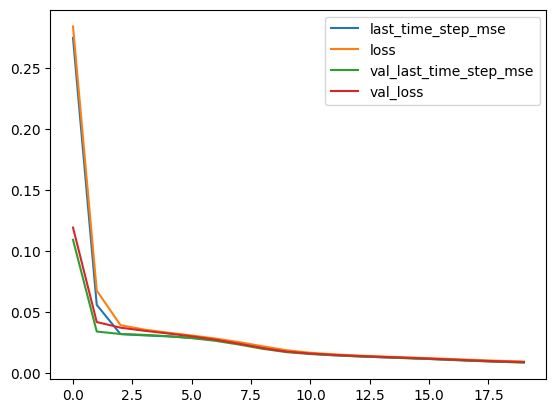

In [376]:
pd.DataFrame(history.history).plot()

In [377]:
model.evaluate(X_valid, Y_valid[:, 3::2])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - last_time_step_mse: 0.0090 - loss: 0.0094


[0.009377764537930489, 0.008994793519377708]

In [381]:
Y_pred = model.predict(X_valid)
Y_pred.shape, Y_valid.shape

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


((296, 27, 14), (296, 56, 14))

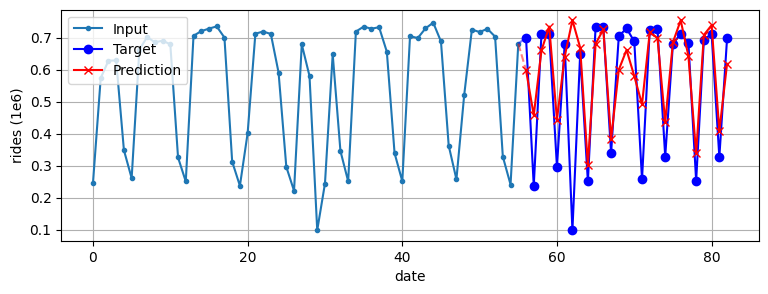

<Figure size 640x480 with 0 Axes>

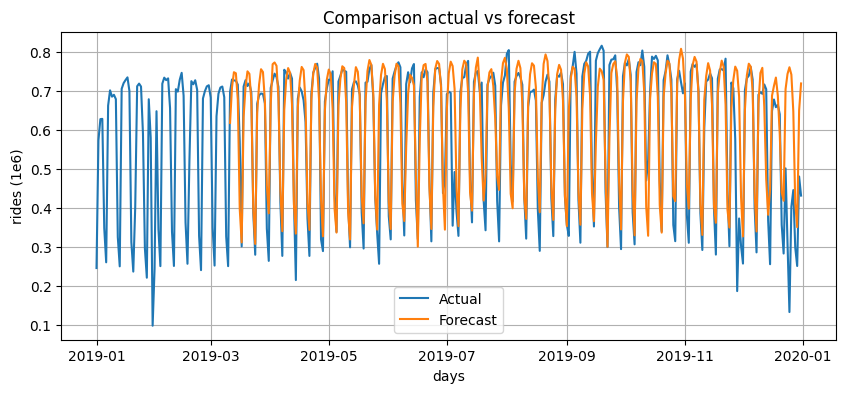

In [384]:
idx=0
plot_window(X_valid[idx], Y_valid[idx, 3::2,-1], Y_pred[idx,...,-1])
plt.figure()
plot_forecast(rail_valid, Y_pred[:,-1,-1])

#### Model 6: WaveNet-like model
##### Why use a WaveNet-like architecture?

WaveNet replaces recurrent layers by stacks of causal convolutions with increasing dilation factors.

This allows the model to capture both short-term and long-term dependencies while remaining fully parallel during training. Unlike RNNs, gradients do not need to propagate through many recurrent steps, which can make optimization easier and training faster.

WaveNet architectures have become a popular alternative to recurrent networks for sequence modelling and forecasting tasks.
``
![Wavenet diagram](http://benanne.github.io/images/wavenet.png)
[From Oord et al., 2016](https://arxiv.org/abs/1609.03499)

In [385]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=[None, 1]))
for rate in (1, 2, 4, 8) * 2:
    model.add(keras.layers.Conv1D(filters=20, kernel_size=2, padding="causal",
                                  activation="relu", dilation_rate=rate))
model.add(keras.layers.Conv1D(filters=ahead, kernel_size=1))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, None, 20)       │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, None, 14)       │           294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,094 (23.80 KB)

 Trainable params: 6,094 (23.80 KB)

 Non-trainable params: 0 (0.00 B)

##### TODO: train the WaveNet model
 - Use the Adam optimizer with the default learning rate
 - Train it it for 20 epochs
 - Don't forget to include your validation data
 - Check the learning curves and the performance on the validation set

In [ ]:
#TODO

In [386]:
#SOLUTION
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - last_time_step_mse: 0.3790 - loss: 0.3845 - val_last_time_step_mse: 0.1968 - val_loss: 0.2189
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - last_time_step_mse: 0.1032 - loss: 0.1262 - val_last_time_step_mse: 0.0515 - val_loss: 0.0657
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - last_time_step_mse: 0.0374 - loss: 0.0512 - val_last_time_step_mse: 0.0327 - val_loss: 0.0394
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - last_time_step_mse: 0.0323 - loss: 0.0365 - val_last_time_step_mse: 0.0322 - val_loss: 0.0346
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - last_time_step_mse: 0.0320 - loss: 0.0336 - val_last_time_step_mse: 0.0319 - val_loss: 0.0331
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - last_time_step_mse: 0.0317 - loss: 0.0324 - val_last_time_step_mse: 0.0315 - val_loss: 0.0322
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - last_time_step_mse: 0.0311 - loss: 0.0315 - val_last_time_step_ms

In [387]:
# saving model stats for later
extra_models['WaveNet']= {'model': model, 'history': history}

<Axes: >

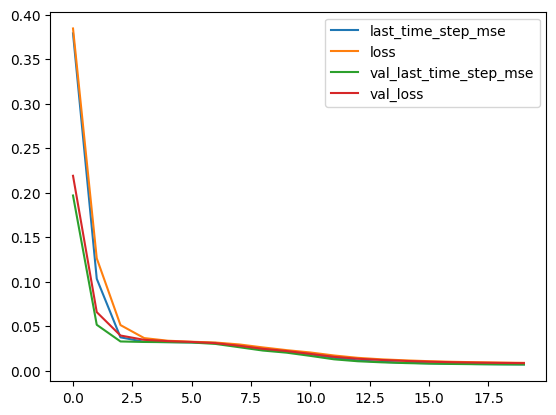

In [388]:
pd.DataFrame(history.history).plot()

In [389]:
model.evaluate(X_valid, Y_valid)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - last_time_step_mse: 0.0069 - loss: 0.0084


[0.008374223485589027, 0.0068652816116809845]

In [390]:
Y_pred = model.predict(X_valid)
Y_pred.shape, Y_valid.shape

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


((296, 56, 14), (296, 56, 14))

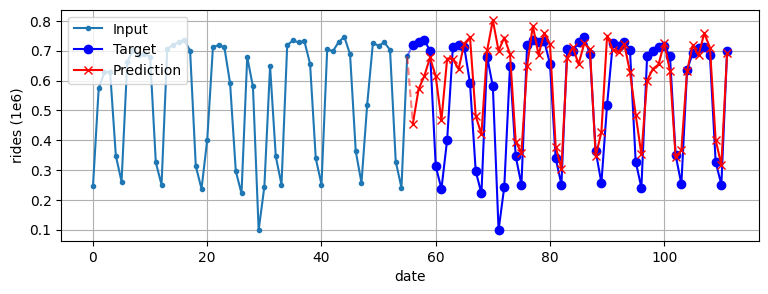

<Figure size 640x480 with 0 Axes>

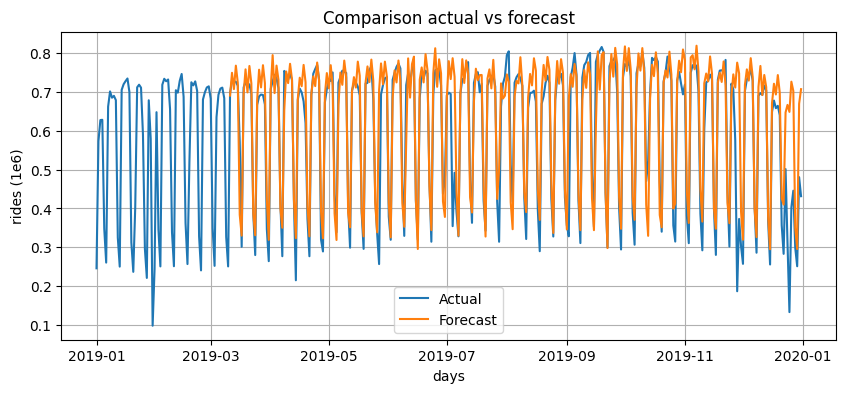

In [392]:
idx=0
plot_window(X_valid[idx], Y_valid[idx, ..., -1], Y_pred[idx,...,-1])
plt.figure()
plot_forecast(rail_valid, Y_pred[:,-1,-1])

#### Result summary wiht extra models

In [393]:
#SOLUTION
all_models = dict()
all_models.update(pred_multi_models)
all_models.update(extra_models)
data = []
for estim, log in all_models.items():
    try:
        val_loss = log['history'].history['last_time_step_mse'][-1]
    except KeyError:
        val_loss = log['history'].history['val_loss'][-1]

    data.append({'Model': estim,
                'Validation loss': val_loss})
pd.DataFrame(data)

,Model,Validation loss
0,linear,0.015473
1,DeepRNN_seq2vec,0.011523
2,DeepRNN_seq2seq,0.007377
3,DeepRNN_LSTM,0.006956
4,DeepRNN_GRU,0.014227
5,DeepRNN_CNN,0.009052
6,WaveNet,0.006969
